# Dataset Description

The Heart Disease Dataset is a medical dataset used to predict whether a patient is likely to have heart disease based on various health-related attributes. The dataset contains **1025 patient records** and 14 features, including demographic information, clinical measurements, and diagnostic test results.

**importring libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve)

**loading dataset**

In [1]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart.csv


In [3]:
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


**explore dataset**

In [4]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(1025, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtyp

**features and target**

In [6]:
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


In [7]:
X = df.drop("target", axis=1)
y = df["target"]

**train-test split & feature scaling**

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,
                                                    stratify=y)

In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**logistic regression**

In [18]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:,1]
print(accuracy_score(y_test,lr_pred))

0.8097560975609757


**SVM**

In [19]:
svm = SVC(
    probability=True,
    kernel='rbf')
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
svm_prob = svm.predict_proba(X_test)[:,1]
print(accuracy_score(y_test,svm_pred))

0.926829268292683


**random forest**

In [21]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]
print(accuracy_score(y_test,rf_pred))

1.0


**evaluating function**

In [13]:
def evaluate_model(name, y_true, pred, prob):
    print("="*50)
    print(name)
    print("="*50)
    print("Accuracy :", accuracy_score(y_true,pred))
    print("Precision:", precision_score(y_true,pred))
    print("Recall   :", recall_score(y_true,pred))
    print("F1 Score :", f1_score(y_true,pred))
    print("ROC AUC  :", roc_auc_score(y_true,prob))
    print("\n")

In [14]:
evaluate_model("Logistic Regression",y_test,lr_pred,lr_prob)
evaluate_model("SVM",y_test,svm_pred,svm_prob)
evaluate_model("Random Forest",y_test,rf_pred,rf_prob)

Logistic Regression
Accuracy : 0.8097560975609757
Precision: 0.7619047619047619
Recall   : 0.9142857142857143
F1 Score : 0.8311688311688312
ROC AUC  : 0.9298095238095239


SVM
Accuracy : 0.926829268292683
Precision: 0.9166666666666666
Recall   : 0.9428571428571428
F1 Score : 0.9295774647887324
ROC AUC  : 0.9771428571428571


Random Forest
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0




**comparision table**

In [24]:
results = pd.DataFrame({
    "Model":["Logistic Regression","SVM","Random Forest"],
    "Accuracy":[accuracy_score(y_test,lr_pred),accuracy_score(y_test,svm_pred),accuracy_score(y_test,rf_pred)],
    "Precision":[precision_score(y_test,lr_pred),precision_score(y_test,svm_pred),precision_score(y_test,rf_pred)],
    "Recall":[recall_score(y_test,lr_pred),recall_score(y_test,svm_pred),recall_score(y_test,rf_pred)],
    "F1 Score":[f1_score(y_test,lr_pred),f1_score(y_test,svm_pred),f1_score(y_test,rf_pred)]})
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.809756,0.761905,0.914286,0.831169
1,SVM,0.926829,0.916667,0.942857,0.929577
2,Random Forest,1.000000,1.000000,1.000000,1.000000


**confusion matrix**

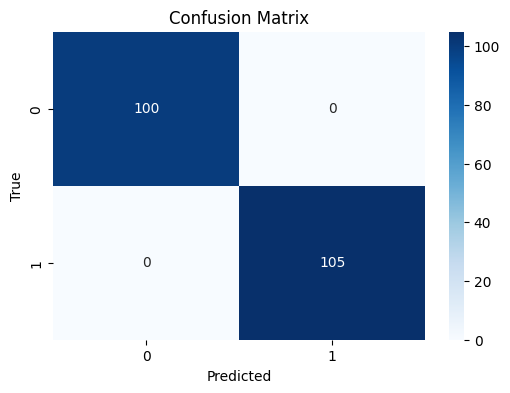

In [28]:
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

**ROC curve**

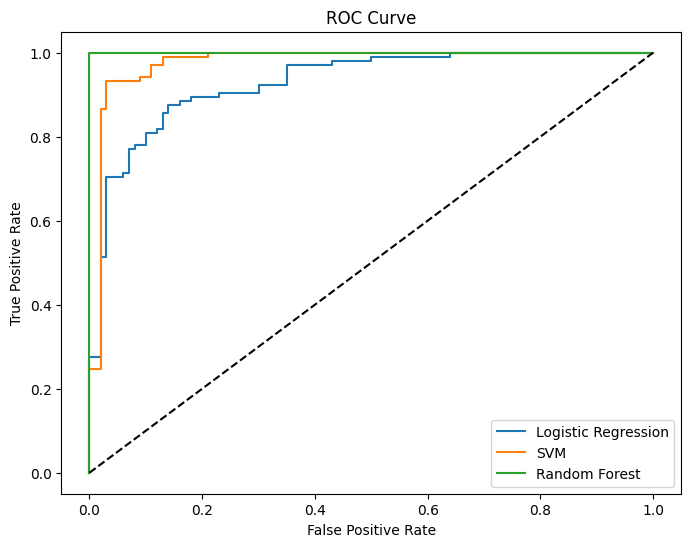

In [27]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
plt.figure(figsize=(8,6))
plt.plot(fpr_lr,tpr_lr,label="Logistic Regression")
plt.plot(fpr_svm,tpr_svm,label="SVM")
plt.plot(fpr_rf,tpr_rf,label="Random Forest")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("ROC Curve")
plt.show()

**feature importance**

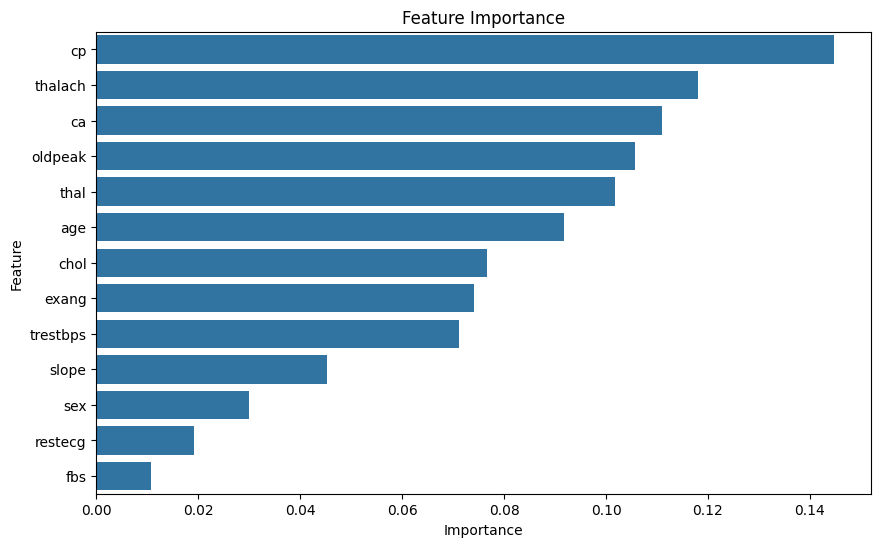

In [29]:
importance = pd.DataFrame({"Feature":X.columns,"Importance":rf.feature_importances_})
importance = importance.sort_values(by="Importance",ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(data=importance,x="Importance",y="Feature")
plt.title("Feature Importance")
plt.show()

**sample prediction**

In [33]:
sample = X_test[13].reshape(1,-1)
prediction = rf.predict(sample)
if prediction[0] == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease Detected")

No Heart Disease Detected
